### SIADS 696

#### Predicting The Predictor: Regime-Based Error Analysis of BondDroid vs. TRACE
#### Supervised Learning

Processed by: Carter Pasternak


The goal with supervised learning is to determine  mispricing between BondDroid and realized TRACE transaction prices. The target is the absolute difference of TRACE trade price and the most recent BondDroid midpoint ((bid+ask)/2). Models include Ridge/Elastic Net, Random Forest, and Gradient Boosting (XGBoost/LightGBM). Features include things like BondDroid quote data, liquidity and trade metrics, maturity, and coupon structure, Treasury benchmarks, and intraday timing. Pricing errors were also examined within latent market regimes identified through K-Means clustering.


Evaluation uses time-based splits to prevent leakage, current outputs are ranked by MAE, and importance is evaluated for the best model (lowest MAE).

##### Pipeline

1. Data loading and merging
    - Merging datasets, and engineering variables

2. Train-Val-Test 
    - Generating split for TVT in machine learning

3. Models

4. Assessing Best Model

5. Ablation testing

6. Failure analysis

In [7]:
!pip install xgboost

In [8]:
import os
import wrds
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [9]:
# machine learning imports
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import shap # using version 0.45.1

### 1. Data Loading and Processing

ML_panel is loaded from paths, and displayed to ensure that it is proper. Cluster labels are loaded from the prepared clustering_labeled file, and a prepared cluster lookup is generated. ml_panel and cluster labels are then merged into one dataset using an asof join.

After the dataset is created and merged, features are engineered from timestamps. This includes converting the trade_side (buy, sell) to numerical outputs (1,0), time since last trade into dummy column, and trade_ts into hour, and dayofweek columns, ttm_year is also created from Maturity which is the maturation date represented in years. Alongside this, quantile ranges are calculated for use with a train-val-test split

In [10]:
path = "/Users/carterpasternak/Downloads" # change to wherever file is installed, I have it in my downloads
ml_path= os.path.join(path, "final_ml_panel.parquet")


ml_df = pl.read_parquet(ml_path)
ml_df = ml_df.sort(["FIGI", "trade_ts"])
ml_df.head()

cusip,trace_price,trace_yield,trade_volume,trade_side,trade_ts,FIGI,REGION_East Asia & Pacific,REGION_Europe and Central Asia,REGION_Latin America and Caribbean,REGION_North America,REGION_South Asia,MARKET_SEGMENT_DM Corporate,MARKET_SEGMENT_EM Corporate,bd_ts,bd_mid_px,bd_mid_yield,bd_px_spread,AVG_DAILY_TRADE_COUNT_60,TIMES_TRADED_60,TIME_SINCE_LAST_TRADE,BID_OAS,ASK_OAS,BID_SOT,ASK_SOT,DURATION_MID,CONVEXITY_MID,COUPON,MATURITY,BONDDROID_SECTOR_Accommodation and Food Services,BONDDROID_SECTOR_Administrative and Support and Waste Management and Remediation Services,"BONDDROID_SECTOR_Arts, Entertainment, and Recreation",BONDDROID_SECTOR_Construction,BONDDROID_SECTOR_Finance and Insurance,BONDDROID_SECTOR_Health Care and Social Assistance,BONDDROID_SECTOR_Information,BONDDROID_SECTOR_Management of Companies and Enterprises,BONDDROID_SECTOR_Manufacturing,"BONDDROID_SECTOR_Mining, Quarrying, and Oil and Gas Extraction","BONDDROID_SECTOR_Professional, Scientific, and Technical Services",BONDDROID_SECTOR_Real Estate and Rental and Leasing,BONDDROID_SECTOR_Retail Trade,BONDDROID_SECTOR_Transportation and Warehousing,BONDDROID_SECTOR_Utilities,BONDDROID_SECTOR_Wholesale Trade,BONDDROID_INDUSTRY,TRIGGER_TYPE_ats1_primary,TRIGGER_TYPE_trace_primary,is_snapshot,bd_pricing_failure,quote_age_seconds,target_abs_error,log_volume,OAS_MID,SOT_MID
str,f64,f64,f64,str,datetime[ns],str,u8,u8,u8,u8,u8,u8,u8,datetime[μs],f32,f32,f32,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,datetime[ms],u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,u8,u8,bool,bool,f32,f32,f32,f32,f32
"""92343VAF1""",97.545,6.526488,5000.0,"""B""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.197177,-0.897342,0.416558,0.284408
"""92343VAF1""",97.608,6.519267,5000.0,"""S""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.260177,-0.897342,0.416558,0.284408
"""92343VAF1""",97.545,6.526488,5000.0,"""S""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.197177,-0.897342,0.416558,0.284408
"""92343VAF1""",97.608,6.519267,5000.0,"""B""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.260177,-0.897342,0.416558,0.284408
"""92343VAF1""",97.582,6.522246,10000.0,"""B""",2023-10-17 11:32:15,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 11:00:02,0.277134,0.454239,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.766443,176.716113,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,0.155775,0.303043,-0.548809,0.416558,0.284059


In [11]:
cluster_path = os.path.join(path, "clustering_labeled.parquet")
cluster_df = pl.read_parquet(cluster_path)


cluster_lookup = (
    cluster_df
    .select(["FIGI", "bd_ts", "cluster"])
    .unique()
    .sort(["FIGI", "bd_ts"])
)

cluster_lookup = cluster_lookup.sort(["FIGI", "bd_ts"])
cluster_lookup.head()

FIGI,bd_ts,cluster
str,datetime[μs],i32
"""BBG00000BHR9""",2023-10-17 10:00:02,2
"""BBG00000BHR9""",2023-10-17 11:00:02,2
"""BBG00000BHR9""",2023-10-17 14:00:01,2
"""BBG00000BHR9""",2023-10-18 10:00:31,2
"""BBG00000BHR9""",2023-10-18 11:00:01,2


In [12]:
# convert timestamps to datetime for asof join
ml_df = ml_df.with_columns(
    pl.col("trade_ts").cast(pl.Datetime("us"))
)

ml_df = ml_df.with_columns(
    pl.col("MATURITY").cast(pl.Datetime("us"))
)

cluster_lookup = cluster_lookup.with_columns(
    pl.col("bd_ts").cast(pl.Datetime("us"))
)

# perform asof join to merge ml_df and cluster_lookup on FIGI and nearest bd_ts <= trade_ts
merged_df = ml_df.join_asof(
    cluster_lookup,
    left_on="trade_ts",
    right_on="bd_ts",
    by="FIGI",
    strategy="backward"
)
merged_df.head()

/var/folders/24/yv4cjz2j4qndh0jby_dyvm_00000gn/T/ipykernel_1590/1708372236.py:15: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  merged_df = ml_df.join_asof(


cusip,trace_price,trace_yield,trade_volume,trade_side,trade_ts,FIGI,REGION_East Asia & Pacific,REGION_Europe and Central Asia,REGION_Latin America and Caribbean,REGION_North America,REGION_South Asia,MARKET_SEGMENT_DM Corporate,MARKET_SEGMENT_EM Corporate,bd_ts,bd_mid_px,bd_mid_yield,bd_px_spread,AVG_DAILY_TRADE_COUNT_60,TIMES_TRADED_60,TIME_SINCE_LAST_TRADE,BID_OAS,ASK_OAS,BID_SOT,ASK_SOT,DURATION_MID,CONVEXITY_MID,COUPON,MATURITY,BONDDROID_SECTOR_Accommodation and Food Services,BONDDROID_SECTOR_Administrative and Support and Waste Management and Remediation Services,"BONDDROID_SECTOR_Arts, Entertainment, and Recreation",BONDDROID_SECTOR_Construction,BONDDROID_SECTOR_Finance and Insurance,BONDDROID_SECTOR_Health Care and Social Assistance,BONDDROID_SECTOR_Information,BONDDROID_SECTOR_Management of Companies and Enterprises,BONDDROID_SECTOR_Manufacturing,"BONDDROID_SECTOR_Mining, Quarrying, and Oil and Gas Extraction","BONDDROID_SECTOR_Professional, Scientific, and Technical Services",BONDDROID_SECTOR_Real Estate and Rental and Leasing,BONDDROID_SECTOR_Retail Trade,BONDDROID_SECTOR_Transportation and Warehousing,BONDDROID_SECTOR_Utilities,BONDDROID_SECTOR_Wholesale Trade,BONDDROID_INDUSTRY,TRIGGER_TYPE_ats1_primary,TRIGGER_TYPE_trace_primary,is_snapshot,bd_pricing_failure,quote_age_seconds,target_abs_error,log_volume,OAS_MID,SOT_MID,bd_ts_right,cluster
str,f64,f64,f64,str,datetime[μs],str,u8,u8,u8,u8,u8,u8,u8,datetime[μs],f32,f32,f32,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,datetime[μs],u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,u8,u8,bool,bool,f32,f32,f32,f32,f32,datetime[μs],i32
"""92343VAF1""",97.545,6.526488,5000.0,"""B""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.197177,-0.897342,0.416558,0.284408,2023-10-17 10:00:02,2
"""92343VAF1""",97.608,6.519267,5000.0,"""S""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.260177,-0.897342,0.416558,0.284408,2023-10-17 10:00:02,2
"""92343VAF1""",97.545,6.526488,5000.0,"""S""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.197177,-0.897342,0.416558,0.284408,2023-10-17 10:00:02,2
"""92343VAF1""",97.608,6.519267,5000.0,"""B""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.260177,-0.897342,0.416558,0.284408,2023-10-17 10:00:02,2
"""92343VAF1""",97.582,6.522246,10000.0,"""B""",2023-10-17 11:32:15,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 11:00:02,0.277134,0.454239,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.766443,176.716113,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,0.155775,0.303043,-0.548809,0.416558,0.284059,2023-10-17 11:00:02,2


In [13]:
print(f'Merged dataset: {merged_df.shape}, ML panel:  {ml_df.shape}, Cluster dataset: {cluster_df.shape}')

merged_df.select(
    pl.col("cluster").is_null().sum()
)

Merged dataset: (8509326, 57), ML panel:  (8509326, 55), Cluster dataset: (8500577, 26)


cluster
u32
183


In [14]:
merged_df = merged_df.drop_nulls(subset=["cluster"])
print(f'Merged dataset after dropping nulls: {merged_df.shape}')
merged_df.select(
    pl.col("cluster").is_null().sum()
)

Merged dataset after dropping nulls: (8509143, 57)


cluster
u32
0


In [15]:

merged_df = merged_df.with_columns([
    pl.col("trade_ts").dt.hour().alias("hour"),
    pl.col("trade_ts").dt.weekday().alias("dayofweek")
])

merged_df = merged_df.with_columns(
    ((pl.col("MATURITY") - pl.col("trade_ts")).dt.total_days() / 365.25).alias("ttm_years")
)

merged_df = merged_df.with_columns(
    pl.col("trade_side").replace({"B": 1, "S": 0}).cast(pl.Int8).alias("trade_side_encoded")
)

merged_df = merged_df.to_dummies(["TIME_SINCE_LAST_TRADE"])

merged_df[["trade_ts", "dayofweek", "hour", "trade_side_encoded","ttm_years"]].head()

trade_ts,dayofweek,hour,trade_side_encoded,ttm_years
datetime[μs],i8,i8,i8,f64
2023-10-17 10:50:39,2,10,1,13.453799
2023-10-17 10:50:39,2,10,0,13.453799
2023-10-17 10:50:39,2,10,0,13.453799
2023-10-17 10:50:39,2,10,1,13.453799
2023-10-17 11:32:15,2,11,1,13.453799


In [16]:
# ensure that the dataframe is sorted by trade timestamp, 
df_final = merged_df.sort("trade_ts") 
df_final.head()

cusip,trace_price,trace_yield,trade_volume,trade_side,trade_ts,FIGI,REGION_East Asia & Pacific,REGION_Europe and Central Asia,REGION_Latin America and Caribbean,REGION_North America,REGION_South Asia,MARKET_SEGMENT_DM Corporate,MARKET_SEGMENT_EM Corporate,bd_ts,bd_mid_px,bd_mid_yield,bd_px_spread,AVG_DAILY_TRADE_COUNT_60,TIMES_TRADED_60,TIME_SINCE_LAST_TRADE_0-24,TIME_SINCE_LAST_TRADE_24-48,TIME_SINCE_LAST_TRADE_48-72,TIME_SINCE_LAST_TRADE_72+,TIME_SINCE_LAST_TRADE_null,BID_OAS,ASK_OAS,BID_SOT,ASK_SOT,DURATION_MID,CONVEXITY_MID,COUPON,MATURITY,BONDDROID_SECTOR_Accommodation and Food Services,BONDDROID_SECTOR_Administrative and Support and Waste Management and Remediation Services,"BONDDROID_SECTOR_Arts, Entertainment, and Recreation",BONDDROID_SECTOR_Construction,BONDDROID_SECTOR_Finance and Insurance,BONDDROID_SECTOR_Health Care and Social Assistance,BONDDROID_SECTOR_Information,BONDDROID_SECTOR_Management of Companies and Enterprises,BONDDROID_SECTOR_Manufacturing,"BONDDROID_SECTOR_Mining, Quarrying, and Oil and Gas Extraction","BONDDROID_SECTOR_Professional, Scientific, and Technical Services",BONDDROID_SECTOR_Real Estate and Rental and Leasing,BONDDROID_SECTOR_Retail Trade,BONDDROID_SECTOR_Transportation and Warehousing,BONDDROID_SECTOR_Utilities,BONDDROID_SECTOR_Wholesale Trade,BONDDROID_INDUSTRY,TRIGGER_TYPE_ats1_primary,TRIGGER_TYPE_trace_primary,is_snapshot,bd_pricing_failure,quote_age_seconds,target_abs_error,log_volume,OAS_MID,SOT_MID,bd_ts_right,cluster,hour,dayofweek,ttm_years,trade_side_encoded
str,f64,f64,f64,str,datetime[μs],str,u8,u8,u8,u8,u8,u8,u8,datetime[μs],f32,f32,f32,f64,f64,u8,u8,u8,u8,u8,f64,f64,f64,f64,f64,f64,f64,datetime[μs],u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,u8,u8,bool,bool,f32,f32,f32,f32,f32,datetime[μs],i32,i8,i8,f64,i8
"""654106AH6""",95.942,5.322702,1.587e6,"""S""",2023-10-05 23:31:28,"""BBG00ST5XXV2""",0,0,0,1,0,1,0,2023-10-05 23:00:01,0.107465,-0.00319,-0.724442,10.45,627.0,1,0,0,0,0,42.701266,41.201266,45.580225,43.25968,1.407324,0.026796,0.024,2025-03-27 00:00:00,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,"""Footwear Manufacturing""",0,1,false,false,0.110315,0.166865,1.999337,-0.499202,-0.27403,2023-10-05 23:00:01,0,23,4,1.472964,0
"""478160CT9""",53.806,5.322042,2000.0,"""B""",2023-10-05 23:49:02,"""BBG00WVM0X12""",0,0,0,1,0,1,0,2023-10-05 23:00:01,-4.637289,-0.051014,-0.111909,7.517,451.02,1,0,0,0,0,48.586054,47.086054,45.540956,44.044912,18.868005,5.385938,0.0245,2060-09-01 00:00:00,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,"""Pharmaceutical and Medicine Ma…",0,1,false,false,1.151922,0.084909,-1.357993,-0.456106,-0.272487,2023-10-05 23:00:01,2,23,4,36.906229,1
"""478160CT9""",53.806,5.322042,2000.0,"""S""",2023-10-05 23:49:02,"""BBG00WVM0X12""",0,0,0,1,0,1,0,2023-10-05 23:00:01,-4.637289,-0.051014,-0.111909,7.517,451.02,1,0,0,0,0,48.586054,47.086054,45.540956,44.044912,18.868005,5.385938,0.0245,2060-09-01 00:00:00,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,"""Pharmaceutical and Medicine Ma…",0,1,false,false,1.151922,0.084909,-1.357993,-0.456106,-0.272487,2023-10-05 23:00:01,2,23,4,36.906229,0
"""61746BEF9""",93.078,5.981461,2000.0,"""B""",2023-10-06 08:00:05,"""BBG00FRY84X9""",0,0,0,1,0,1,0,2023-10-06 08:00:01,-0.203591,0.225912,-0.377787,93.917,5635.02,1,0,0,0,0,119.831021,116.289217,131.440395,127.892733,2.998614,0.108055,0.03625,2027-01-20 00:00:00,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,"""Portfolio Management """,0,1,true,false,-1.750544,0.059834,-1.357993,0.058168,0.078846,2023-10-06 08:00:01,3,8,5,3.288159,1
"""61746BEF9""",93.078,5.981461,2000.0,"""S""",2023-10-06 08:00:05,"""BBG00FRY84X9""",0,0,0,1,0,1,0,2023-10-06 08:00:01,-0.203591,0.225912,-0.377787,93.917,5635.02,1,0,0,0,0,119.831021,116.289217,131.440395,127.892733,2.998614,0.108055,0.03625,2027-01-20 00:00:00,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,"""Portfolio Management """,0,1,true,false,-1.750544,0.059834,-1.357993,0.058168,0.078846,2023-10-06 08:00:01,3,8,5,3.288159,0


#### 2. Train-Val-Test (TVT)
After the datasets are merged and features are engineered, a train-val-test split is created based on the timeframe to ensure data leakage is mitigated. This is done using a function to make the X and Y values ensuring reproducability. 

Exact timestamps were excluded from modeling to prevent the model from learning date specific effects. Instead, cyclical information such as hour of day, and day of week features are used. Raw features are removed where engineered features exist, and targets are removed, along with the features that directly calculate them. Data leakage is also removed, which includes trace price, which may only be known at the time of the sale/purchase of a bond.

In [17]:
# Check the breakdown of the time series data, this is used for setting train test split so that time frame is 70-15-15, ensuring that temporal leakage is mitigated and the model is not trained on data that is too close to the test set
df_final["trade_ts"].quantile([0.7, 0.85])

[datetime.datetime(2024, 10, 9, 10, 0, 53),
 datetime.datetime(2025, 1, 6, 11, 33, 27)]

In [ ]:
df_final = df_final.to_pandas()
train_end = pd.Timestamp("2024-10-09 09:58:12")
val_end = pd.Timestamp("2025-01-06 11:32:52")

train = df_final[df_final["trade_ts"] <= train_end]

val = df_final[
    (df_final["trade_ts"] > train_end) &
    (df_final["trade_ts"] <= val_end)
]

test = df_final[df_final["trade_ts"] > val_end]

test_eval = test.copy() #this is the test set that will be used for final evaluation

#### 3. Baseline Models

Use the dataset and TVT split with features to test supervised learning and examine pricing failures without regimes.

Ridge -

Lasso -



In [19]:
drop_cols = [
    #target
    "target_abs_error", 
    "bd_pricing_failure",
    
    #leakage 
    "trace_price", 
    "bd_mid_px",
    "trace_yield", 

    #identifiers
    "cusip",
    "FIGI",
    "BONDDROID_INDUSTRY", #engineered feature is used instead
    "cluster",
    
    #timestamps
    "trade_ts", # not needed, as it may cause leakage or over estimation, will use hour/day instead
    "bd_ts", "bd_ts_right", # from the merge, not needed, as it may cause leakage or over estimation, will use hour/day instead
    "MATURITY",
    
    #encoded features
    "trade_side",
    "TIME_SINCE_LAST_TRADE",
    
    
    #
    "BID_SOT", "ASK_SOT",
    "BID_OAS", "ASK_OAS",
    
    #raw volume
    "trade_volume", "AVG_DAILY_TRADE_COUNT_60", "TIMES_TRADED_60"
    ] 

def make_xy(df):
    X = df.drop(columns= drop_cols
    , errors="ignore").copy()

    y =df["target_abs_error"].copy()

    return X, y

In [20]:
# create X and Y for train, val and test sets

X_train, y_train = make_xy(train) 
X_val, y_val = make_xy(val)
X_test, y_test = make_xy(test)

#### Ridge Regression:

In [21]:
alphas = [0.01,0.1, 1.0, 10.0, 100.0, 1000.0]
best_mae = float("inf")

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


for a in alphas:
    ridge_model = Ridge(alpha=a)
    ridge_model.fit(X_train_s, y_train)
    val_pred = ridge_model.predict(X_val_s)
    val_mae = mean_absolute_error(y_val, val_pred)
    print(f"Alpha: {a}, Validation MAE: {val_mae}")
    
    if val_mae < best_mae:
        best_mae = val_mae
        best_alpha = a
print(best_mae, best_alpha)


Alpha: 0.01, Validation MAE: 0.3358719831004137
Alpha: 0.1, Validation MAE: 0.33587087092240614
Alpha: 1.0, Validation MAE: 0.3358704715929504
Alpha: 10.0, Validation MAE: 0.33586755033104465
Alpha: 100.0, Validation MAE: 0.33583848923874476
Alpha: 1000.0, Validation MAE: 0.3355521864125918
0.3355521864125918 1000.0


In [22]:
ridge_model = Ridge(alpha=a)
ridge_model.fit(X_train_s, y_train)
test_pred = ridge_model.predict(X_test_s)
ridge_mae = mean_absolute_error(y_test, test_pred)
print(f"Validation MAE: {ridge_mae}")

Validation MAE: 0.39411914809526255


Validation MAE: 0.39411914809526255

In [23]:
coef_df_r = {}

for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    
    model = Ridge(alpha=best_alpha)
    model.fit(X_s, y)
    
    coef_df_r[c] = pd.DataFrame({
        "feature": X.columns,
        "coefficient": model.coef_,
        "abs_coefficient": np.abs(model.coef_)
    }).sort_values(by="abs_coefficient", ascending=False)
    print(f"Cluster {c} - Top 5 Features by Absolute Coefficient Value:")
    print(coef_df_r[c].head(5))
    

Cluster 0 - Top 5 Features by Absolute Coefficient Value:
         feature  coefficient  abs_coefficient
42     ttm_years     0.161328         0.161328
14  DURATION_MID    -0.102562         0.102562
39       SOT_MID    -0.059115         0.059115
7   bd_mid_yield     0.058547         0.058547
8   bd_px_spread     0.037896         0.037896
Cluster 1 - Top 5 Features by Absolute Coefficient Value:
          feature  coefficient  abs_coefficient
15  CONVEXITY_MID     1.061255         1.061255
14   DURATION_MID    -0.739679         0.739679
42      ttm_years    -0.665438         0.665438
38        OAS_MID     0.631203         0.631203
8    bd_px_spread     0.481772         0.481772
Cluster 2 - Top 5 Features by Absolute Coefficient Value:
                               feature  coefficient  abs_coefficient
38                             OAS_MID    -0.366196         0.366196
39                             SOT_MID     0.337920         0.337920
16                              COUPON     0.2064

#### Lasso Regression:

In [24]:
best_mae = float("inf")
for a in alphas:
    lasso_model = Lasso(alpha=a, max_iter=10000)
    lasso_model.fit(X_train_s, y_train)
    val_pred = lasso_model.predict(X_val_s)
    val_mae = mean_absolute_error(y_val, val_pred)
    print(f"Alpha: {a}, Validation MAE: {val_mae}")
    
    if val_mae < best_mae:
        best_mae = val_mae
        best_alpha = a
print(best_mae, best_alpha)

Alpha: 0.01, Validation MAE: 0.3037241018380943
Alpha: 0.1, Validation MAE: 0.30817229800151785
Alpha: 1.0, Validation MAE: 0.3351202692773466
Alpha: 10.0, Validation MAE: 0.3351202692773466
Alpha: 100.0, Validation MAE: 0.3351202692773466
Alpha: 1000.0, Validation MAE: 0.3351202692773466
0.3037241018380943 0.01


In [25]:
lasso_model = Lasso(alpha=0.01, max_iter=10000)
lasso_model.fit(X_train_s, y_train)
test_pred = lasso_model.predict(X_test_s)
lasso_mae = mean_absolute_error(y_test, test_pred)

print(f"Final MAE: {lasso_mae}")

Final MAE: 0.3173517204038546


Final MAE: 0.3173517204038546

In [26]:
coef_df_l = {}
for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    
    model = Lasso(alpha=best_alpha,max_iter=10000)
    model.fit(X_s, y)
    
    coef_df_l[c] = pd.DataFrame({
        "feature": X.columns,
        "coefficient": model.coef_,
        "abs_coefficient": np.abs(model.coef_)
    }).sort_values(by="abs_coefficient", key=abs, ascending=False)
    print(f"Cluster {c} - Top 5 Features by Absolute Coefficient Value:")
    print(coef_df_l[c].head(5))
    

Cluster 0 - Top 5 Features by Absolute Coefficient Value:
                         feature  coefficient  abs_coefficient
42                     ttm_years     0.036373         0.036373
8                   bd_px_spread     0.025857         0.025857
40                          hour    -0.003198         0.003198
43            trade_side_encoded    -0.002964         0.002964
23  BONDDROID_SECTOR_Information    -0.001035         0.001035
Cluster 1 - Top 5 Features by Absolute Coefficient Value:
          feature  coefficient  abs_coefficient
15  CONVEXITY_MID     1.208274         1.208274
14   DURATION_MID    -0.816516         0.816516
42      ttm_years    -0.747547         0.747547
38        OAS_MID     0.622737         0.622737
8    bd_px_spread     0.492491         0.492491
Cluster 2 - Top 5 Features by Absolute Coefficient Value:
                               feature  coefficient  abs_coefficient
2   REGION_Latin America and Caribbean     0.260206         0.260206
16                    

#### LGBM Regression

Testing LGBM Regression evaluating based on MAE. Columns had to be renamed as LGBM did not support characters.

In [27]:
def clean_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[^0-9a-zA-Z_]+", "_", col).strip("_")
        for col in df.columns
    ]
    return df

In [28]:
X_train_lgb = clean_feature_names(X_train)
X_val_lgb   = clean_feature_names(X_val)
X_test_lgb  = clean_feature_names(X_test)

lgbm_model = LGBMRegressor(random_state=42)


lgbm_model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)], eval_metric="mae")

test_pred_lgb = lgbm_model.predict(X_test_lgb)

test_mae_lgb = mean_absolute_error(y_test, test_pred_lgb)
print("FINAL TEST MAE (LightGBM):", test_mae_lgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.119164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2636
[LightGBM] [Info] Number of data points in the train set: 5956349, number of used features: 43
[LightGBM] [Info] Start training from score 0.417257
FINAL TEST MAE (LightGBM): 0.37263427343926814


FINAL TEST MAE (LightGBM): 0.37263427343926814

In [29]:
coef_df_lgb = {}
for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    X_lgb = clean_feature_names(X)
    
    model =  LGBMRegressor(random_state=42)
    model.fit(X_lgb, y)
    
    coef_df_lgb[c] = pd.DataFrame({
        "feature": X.columns,
        "Importance":  model.booster_.feature_importance(importance_type="gain")
    }).sort_values(by="Importance", key=abs, ascending=False)
    print(f"Cluster {c} - Top 5 Features by Importance:")
    print(coef_df_lgb[c].head(5))
    

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2561
[LightGBM] [Info] Number of data points in the train set: 779279, number of used features: 40
[LightGBM] [Info] Start training from score 0.202261
Cluster 0 - Top 5 Features by Importance:
         feature    Importance
16        COUPON  86344.329281
14  DURATION_MID  44129.902830
37    log_volume  35507.328114
42     ttm_years  26271.252780
8   bd_px_spread  23476.520019
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002571 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2421
[LightGBM] [Info] Number of data points in the train set: 73763, number of used features: 32
[LightGBM] [

#### XGBoost

In [30]:
best_mae = float("inf") 
best_params = {}

for md in [2,4,6]:
    for n_est in [50,100,200,1000]:
        xgb_model = XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_estimators=n_est,
                max_depth=md,
                learning_rate=0.1,
                eval_metric="mae"
            )

        xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        val_pred = xgb_model.predict(X_val)
        val_mae = mean_absolute_error(y_val, val_pred)
                
        if val_mae < best_mae:
            best_mae = val_mae
            best_params = {"max_depth": md,
                            "n_estimators": n_est
                            }

                
print("BEST MAE (XGBoost):", best_mae)
print("BEST PARAMS (XGBoost):", best_params)

BEST MAE (XGBoost): 0.29525697231292725
BEST PARAMS (XGBoost): {'max_depth': 2, 'n_estimators': 50}


BEST MAE (XGBoost): 0.29525697231292725
BEST PARAMS (XGBoost): {'max_depth': 2, 'n_estimators': 50}

In [42]:
best_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    eval_metric="mae",
)

best_xgb.fit(X_train, y_train)

test_pred_xgb = best_xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, test_pred_xgb)
importance_xgb_com = pd.DataFrame({
        "feature": X.columns,
        "Importance":  model.feature_importances_
    }).sort_values(by="Importance", key=abs, ascending=False)

print("FINAL TEST MAE:", xgb_mae)

FINAL TEST MAE: 0.2902626395225525


In [32]:
coef_df_xgb = {}
for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    
    model =  XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_estimators=50,
                max_depth=2,
                learning_rate=0.1,
                eval_metric="mae"
            )
    model.fit(X, y)
    
    coef_df_xgb[c] = pd.DataFrame({
        "feature": X.columns,
        "Importance":  model.feature_importances_
    }).sort_values(by="Importance", key=abs, ascending=False)
    print(f"Cluster {c} - Top 5 Features by Importance:")
    print(coef_df_xgb[c].head(5))
    

Cluster 0 - Top 5 Features by Importance:
                                              feature  Importance
36                                  quote_age_seconds    0.641480
14                                       DURATION_MID    0.160541
27  BONDDROID_SECTOR_Professional, Scientific, and...    0.056573
42                                          ttm_years    0.035963
16                                             COUPON    0.021539
Cluster 1 - Top 5 Features by Importance:
                               feature  Importance
38                             OAS_MID    0.598499
14                        DURATION_MID    0.078141
12           TIME_SINCE_LAST_TRADE_72+    0.071395
2   REGION_Latin America and Caribbean    0.062861
15                       CONVEXITY_MID    0.048684
Cluster 2 - Top 5 Features by Importance:
          feature  Importance
15  CONVEXITY_MID    0.288914
38        OAS_MID    0.155494
14   DURATION_MID    0.147683
8    bd_px_spread    0.093045
16         COUPON    0

#### Random Forest

In [33]:
for md in [4,6,8]:
    for n_est in [100,200]:
        rf = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=md,
        random_state=42,
        n_jobs=-1)

        rf.fit(X_train, y_train)

        val_pred = rf.predict(X_val)
        val_mae = mean_absolute_error(y_val, val_pred)
                
        if val_mae < best_mae:
            best_mae = val_mae
            best_params = {"max_depth": md,
                            "n_estimators": n_est
                            }
                
print("BEST MAE (RF):", best_mae)
print("BEST PARAMS (RF):", best_params)

BEST MAE (RF): 0.29000112869240885
BEST PARAMS (RF): {'max_depth': 4, 'n_estimators': 100}


In [34]:
rf_best = RandomForestRegressor(
        n_estimators=100,
        max_depth=4,
        random_state=42,
        n_jobs=-1)

rf_best.fit(X_train, y_train)

rf_best_pred = rf.predict(X_test)
rf_best_mae = mean_absolute_error(y_test, val_pred)

importance_rf_com = pd.DataFrame({
        "feature": X.columns,
        "Importance":  rf_best.feature_importances_
    }).sort_values(by="Importance", key=abs, ascending=False)

print("FINAL TEST MAE:", rf_best_mae)
print("Importances:", importance_rf_com )

FINAL TEST MAE: 0.3890311359173649
Importances:                                               feature    Importance
38                                            OAS_MID  3.803263e-01
8                                        bd_px_spread  2.523445e-01
40                                               hour  1.957881e-01
16                                             COUPON  7.357322e-02
14                                       DURATION_MID  3.732960e-02
39                                            SOT_MID  1.584270e-02
25                     BONDDROID_SECTOR_Manufacturing  1.414632e-02
15                                      CONVEXITY_MID  1.397114e-02
42                                          ttm_years  1.207728e-02
7                                        bd_mid_yield  2.305285e-03
36                                  quote_age_seconds  1.997040e-03
12                          TIME_SINCE_LAST_TRADE_72+  2.985219e-04
41                                          dayofweek  5.089345e-10


In [35]:
importances_rf={}
for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    model =  RandomForestRegressor(
        n_estimators=100,
        max_depth=4,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X, y)
    
    importances_rf[c] = pd.DataFrame({
        "feature": X.columns,
        "Importance":  model.feature_importances_
    }).sort_values(by="Importance", key=abs, ascending=False)
    print(f"Cluster {c} - Top 5 Features by Importance:")
    print(importances_rf[c].head(5))

Cluster 0 - Top 5 Features by Importance:
              feature  Importance
16             COUPON    0.302346
15      CONVEXITY_MID    0.138538
40               hour    0.106530
36  quote_age_seconds    0.087924
42          ttm_years    0.086592
Cluster 1 - Top 5 Features by Importance:
          feature  Importance
38        OAS_MID    0.615861
14   DURATION_MID    0.164651
42      ttm_years    0.091323
15  CONVEXITY_MID    0.062964
8    bd_px_spread    0.024645
Cluster 2 - Top 5 Features by Importance:
                               feature  Importance
39                             SOT_MID    0.230299
16                              COUPON    0.169527
7                         bd_mid_yield    0.119293
2   REGION_Latin America and Caribbean    0.105722
8                         bd_px_spread    0.090238
Cluster 3 - Top 5 Features by Importance:
         feature  Importance
42     ttm_years    0.340113
8   bd_px_spread    0.222103
7   bd_mid_yield    0.078363
37    log_volume    0.0777

#### Assessing the best model

In [36]:
results = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Random Forest", "LightGBM", "XGBoost"],
    "MAE": [
        ridge_mae,
        lasso_mae,
        rf_best_mae,
        test_mae_lgb,
        xgb_mae
    ]
})

results = results.sort_values("MAE")

print(results)

           Model       MAE
4        XGBoost  0.290263
1          Lasso  0.317352
3       LightGBM  0.372634
2  Random Forest  0.389031
0          Ridge  0.394119


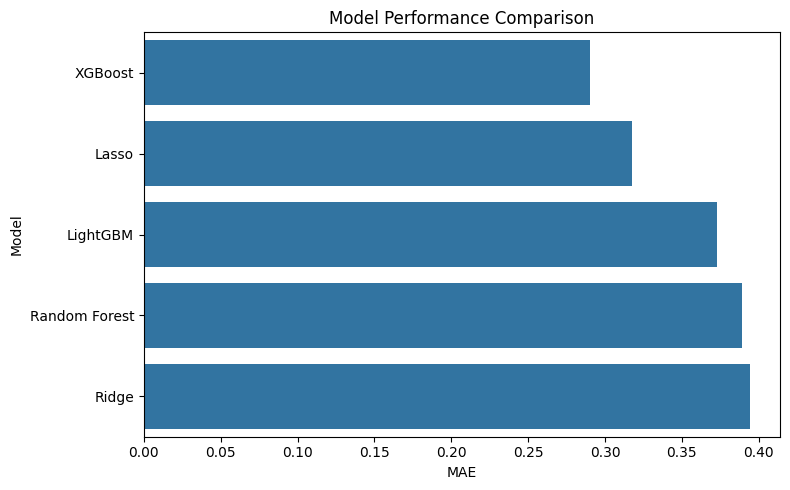

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="MAE",
    y="Model"
)

plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

     model        mae      rank
    XGBoost    0.290263     1
    Lasso      0.317352     2
    RF         0.331229     3
    LGBM       0.372634     4
    Ridge      0.394119     5

In [ ]:
#RERUNNING TO PLOT
xgb_results = []

for md in [2,4,6]:
    for n_est in [50,100,200,1000]:

        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_estimators=n_est,
            max_depth=md,
            learning_rate=0.1,
            eval_metric="mae"
        )

        model.fit(X_train, y_train, verbose=False)

        pred = model.predict(X_val)

        xgb_results.append({
            "max_depth": md,
            "n_estimators": n_est,
            "mae": mean_absolute_error(y_val, pred)
        })

xgb_results = pd.DataFrame(xgb_results)

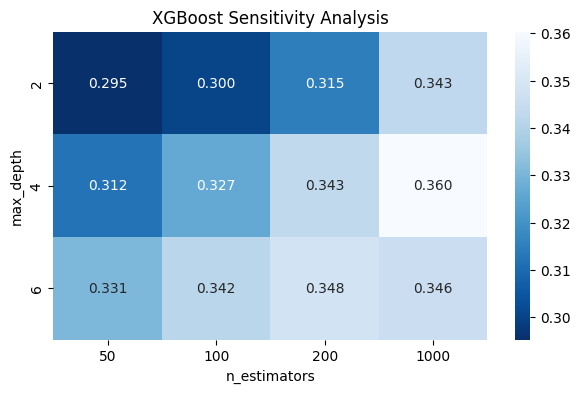

In [44]:
heat = xgb_results.pivot(
    index="max_depth",
    columns="n_estimators",
    values="mae"
)

plt.figure(figsize=(7,4))

sns.heatmap(
    heat,
    annot=True,
    fmt=".3f",
    cmap="Blues_r"
)

plt.title("XGBoost Sensitivity Analysis")
plt.show()

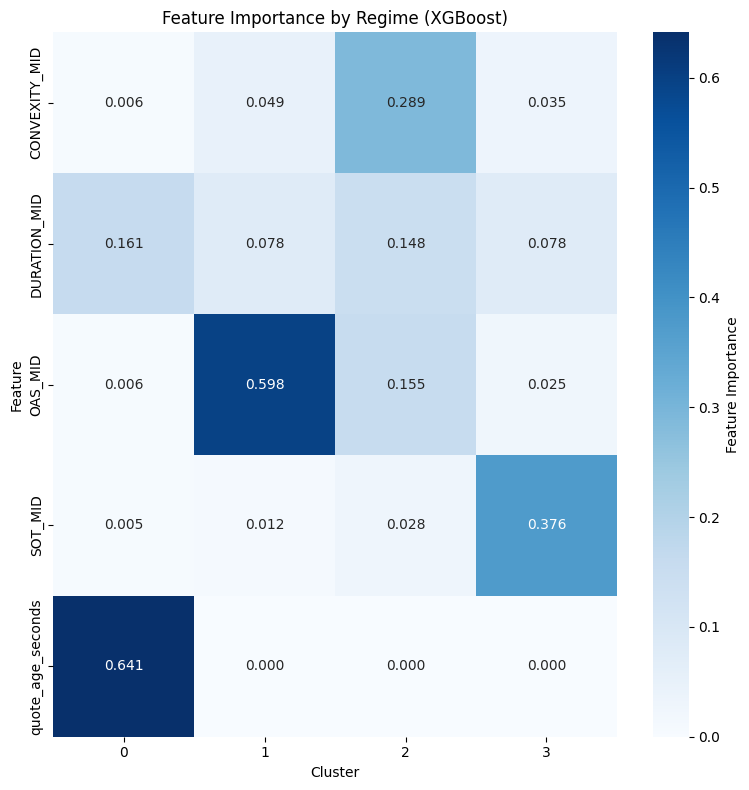

In [ ]:
all_features = pd.concat(
    [imp.assign(cluster=c) for c, imp in coef_df_xgb.items()]
)

#top features by average importance across clusters
top_features = (
    all_features.groupby("feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered = all_features[
    all_features["feature"].isin(top_features)
]

importance_heatmap = filtered.pivot_table(
    index="feature",
    columns="cluster",
    values="Importance",
    fill_value=0
)

plt.figure(figsize=(8,8))
sns.heatmap(
    importance_heatmap,
    annot=True,
    fmt=".3f",
    square=True,
    cmap="Blues",
    cbar_kws={"label": "Feature Importance"}
)

plt.title("Feature Importance by Regime (XGBoost)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

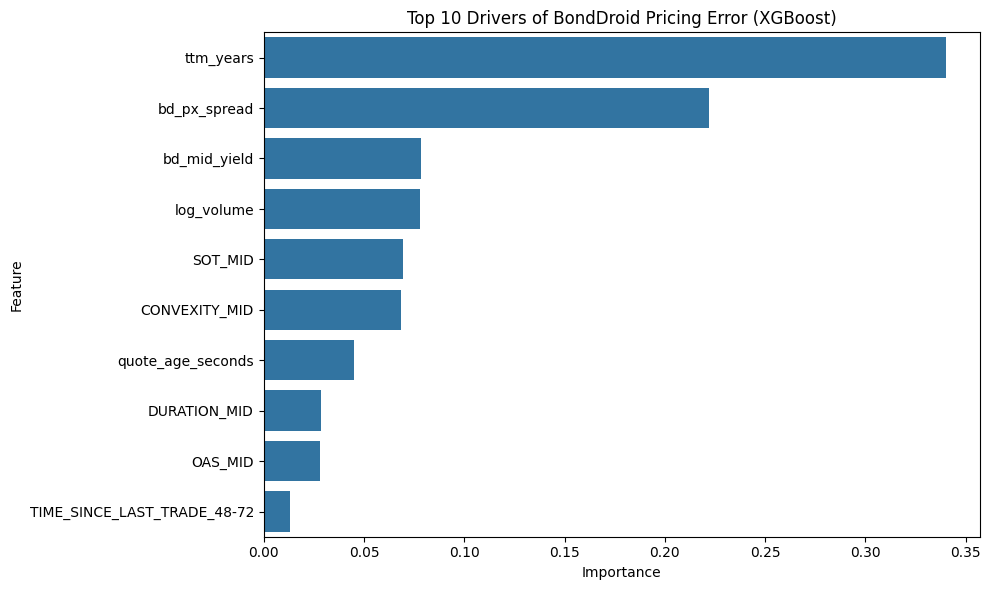

In [46]:
top = importance_xgb_com.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top, x="Importance", y="feature")
plt.title("Top 10 Drivers of BondDroid Pricing Error (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

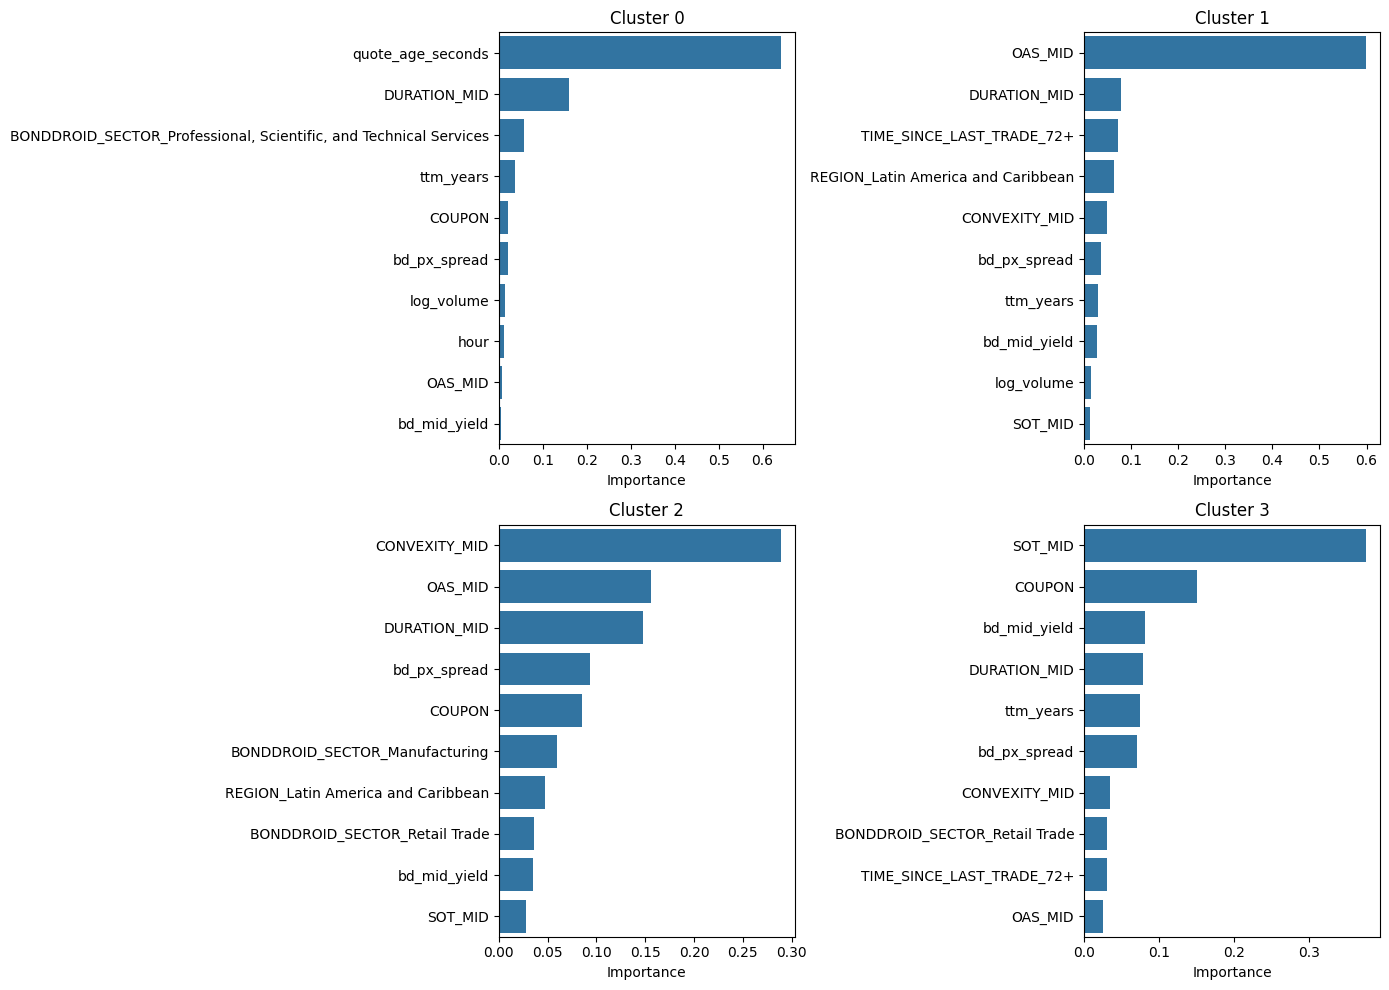

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, (c, imp) in enumerate(sorted(coef_df_xgb.items())):

    top_c = imp.head(10)

    sns.barplot(
        data=top_c,
        x="Importance",
        y="feature",
        ax=axes[i]
    )

    axes[i].set_title(f"Cluster {c}")
    axes[i].set_xlabel("Importance")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

#### ABLATION TESTING

Removing features based on what they describe. OAS, liquidity, or bond features like time, convexity etc.

In [48]:
baseline_mae = xgb_mae

OAS

In [152]:
drop_feats = ["OAS_MID"]

ablation_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=50,
    max_depth=2,
    eval_metric="mae"
)

ablation_model.fit(
    X_train.drop(columns=drop_feats),
    y_train
)

pred = ablation_model.predict(
    X_test.drop(columns=drop_feats)
)

oas_mae = mean_absolute_error(y_test, pred)

Liquidity

In [153]:
drop_feats = [
    "log_volume",
    "quote_age_seconds",
    "bd_px_spread"
]

ablation_model.fit(
    X_train.drop(columns=drop_feats),
    y_train
)

pred = ablation_model.predict(
    X_test.drop(columns=drop_feats)
)

liq_mae = mean_absolute_error(y_test, pred)

Bond Descriptions

In [154]:
drop_feats = [
    "DURATION_MID",
    "CONVEXITY_MID",
    "COUPON",
    "ttm_years"
]

ablation_model.fit(
    X_train.drop(columns=drop_feats),
    y_train
)

pred = ablation_model.predict(
    X_test.drop(columns=drop_feats)
)

bond_mae = mean_absolute_error(y_test, pred)

In [155]:
ablation = pd.DataFrame({
    "Model": [
        "Full",
        "No OAS",
        "No Liquidity",
        "No Bond Features"
    ],
    "MAE": [
        baseline_mae,
        oas_mae,
        liq_mae,
        bond_mae
    ]
})

ablation

,Model,MAE
0,Full,0.290263
1,No OAS,0.319378
2,No Liquidity,0.323352
3,No Bond Features,0.342459


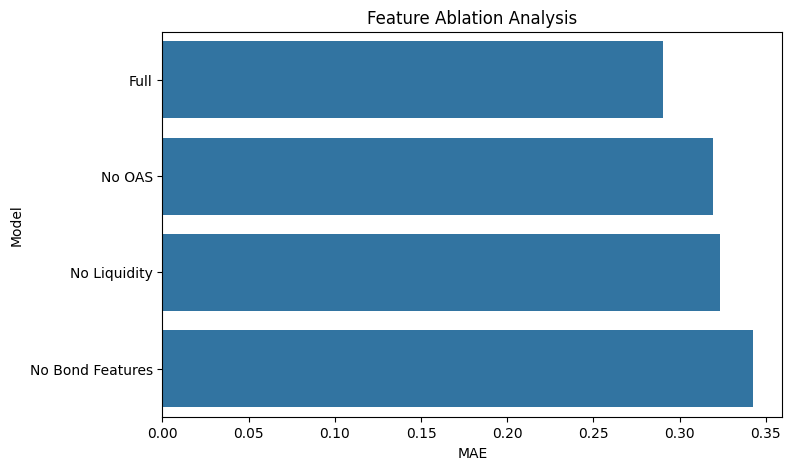

In [156]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=ablation,
    x="MAE",
    y="Model"
)

plt.title("Feature Ablation Analysis")
plt.show()

#### FAILURE ANALYSIS

Examining points of failure in modeling, and what features cause this. Looking at each cluster, how certain clusters dominate, and features inside of clusters based on total feature importance

In [73]:
fail_analysis = test_eval.copy()

fail_analysis["pred"] = test_pred_xgb
fail_analysis["target_abs_error"] = fail_analysis["target_abs_error"]

fail_analysis["abs_residual"] = np.abs(fail_analysis["pred"] - fail_analysis["target_abs_error"])

In [158]:
cols = [
    "cluster",
    "target_abs_error",
    "pred",
    "abs_residual",
    "bd_px_spread",
    "bd_mid_yield",
    "quote_age_seconds",
    "log_volume",
    "OAS_MID",
    "SOT_MID",
    "COUPON",
    "ttm_years"
]

In [159]:
top_failures = fail_analysis.sort_values("target_abs_error", ascending=False)[cols].head(50)
top_failures.head(50)

,cluster,target_abs_error,pred,abs_residual,bd_px_spread,bd_mid_yield,quote_age_seconds,log_volume,OAS_MID,SOT_MID,COUPON,ttm_years
7544374,0,98.565834,0.153975,98.411858,-0.724442,-0.446098,1.802186,-1.357993,-0.560737,-0.422443,0.0325,1.084189
7544373,0,98.565834,0.149912,98.415924,-0.724442,-0.446098,1.802186,-1.357993,-0.560737,-0.422443,0.0325,1.084189
8194074,2,93.503227,0.700799,92.802429,0.238544,-0.120928,0.442365,2.355936,-0.354688,-0.202622,0.0465,20.982888
8194073,2,93.503227,0.704863,92.798363,0.238544,-0.120928,0.442365,2.355936,-0.354688,-0.202622,0.0465,20.982888
8195334,2,57.326126,0.637024,56.689102,-0.135205,-0.167878,1.673714,2.084541,-0.454470,-0.240006,0.0205,25.456537
8195333,2,57.326126,0.632960,56.693165,-0.135205,-0.167878,1.673714,2.084541,-0.454470,-0.240006,0.0205,25.456537
8287220,2,33.217457,4.320084,28.897373,0.488216,-0.095067,1.197381,0.464440,-0.206406,-0.064756,0.0720,14.020534
8287221,2,33.217457,4.316020,28.901436,0.488216,-0.095067,1.197381,0.464440,-0.206406,-0.064756,0.0720,14.020534
8118190,2,33.165131,6.081855,27.083275,0.459349,-0.100112,-1.534119,0.609113,-0.222222,-0.081343,0.0720,14.045175
8357769,3,33.150101,4.419222,28.730879,0.671039,-0.067773,0.357376,-0.728159,-0.120695,-0.015534,0.0720,14.006845


In [ ]:
# features were top of importance in XGBoost
features = [
    "bd_px_spread",
    "bd_mid_yield",
    "quote_age_seconds",
    "log_volume",
    "OAS_MID",
    "SOT_MID",
    "COUPON",
    "ttm_years"
]

# calculates the average feature for each cluster creating a baseline
cluster_analysis = fail_analysis.groupby("cluster")[features].mean()
cluster_analysis

,bd_px_spread,bd_mid_yield,quote_age_seconds,log_volume,OAS_MID,SOT_MID,COUPON,ttm_years
cluster,,,,,,,,
0,-0.545725,-0.282146,-0.005607,-0.068858,-0.409484,-0.239058,0.037395,3.982180
1,1.980108,1.235249,0.138412,-0.653405,2.511571,1.248098,0.066120,7.505175
2,0.838615,0.107186,-0.097107,0.442764,-0.064511,-0.003373,0.046549,23.953964
3,0.097429,0.055946,0.021790,0.072149,0.121806,0.049230,0.054359,6.910515


In [ ]:
# function to explain failure by comparing it to the baseline (average)
def explain_fail(row, cluster_analysis):
    
    #identifies the cluster
    c = row["cluster"]
    
    #retrieves the mean values for cluster
    mean = cluster_analysis.loc[c]
    
    # takes the deviation of  features from the average
    diff = row[features] - mean
    
    # creates a df with the actual value, cluster average, and deviation
    explanation = pd.DataFrame({
        "feature":features,
        "value": row[features],
        "cluster_mean": mean.values,
        "deviation": diff.values
    }).sort_values("deviation", key=abs, ascending=False) #sorts by the largest absolute deviation
    
    return explanation

In [ ]:
#these were identified by  the top_failures.head(50) command earlier, were chosen as they  all belong to different clusters 
ex1 = top_failures.iloc[0]
ex2 = top_failures.iloc[5]
ex3 = top_failures.iloc[48]

In [163]:
exp1 = explain_fail(ex1, cluster_analysis)
exp2 = explain_fail(ex2, cluster_analysis)
exp3 = explain_fail(ex3, cluster_analysis)

In [164]:
exp1

,feature,value,cluster_mean,deviation
ttm_years,ttm_years,1.084189,3.982180,-2.897991
quote_age_seconds,quote_age_seconds,1.802186,-0.005607,1.807793
log_volume,log_volume,-1.357993,-0.068858,-1.289134
SOT_MID,SOT_MID,-0.422443,-0.239058,-0.183385
bd_px_spread,bd_px_spread,-0.724442,-0.545725,-0.178717
bd_mid_yield,bd_mid_yield,-0.446098,-0.282146,-0.163952
OAS_MID,OAS_MID,-0.560737,-0.409484,-0.151253
COUPON,COUPON,0.032500,0.037395,-0.004895


In [165]:
exp2

,feature,value,cluster_mean,deviation
quote_age_seconds,quote_age_seconds,1.673714,-0.097107,1.770822
log_volume,log_volume,2.084541,0.442764,1.641777
ttm_years,ttm_years,25.456537,23.953964,1.502572
bd_px_spread,bd_px_spread,-0.135205,0.838615,-0.973820
OAS_MID,OAS_MID,-0.454470,-0.064511,-0.389959
bd_mid_yield,bd_mid_yield,-0.167878,0.107186,-0.275065
SOT_MID,SOT_MID,-0.240006,-0.003373,-0.236633
COUPON,COUPON,0.020500,0.046549,-0.026049


In [166]:
exp3

,feature,value,cluster_mean,deviation
ttm_years,ttm_years,14.138261,6.910515,7.227747
log_volume,log_volume,0.802859,0.072149,0.730710
quote_age_seconds,quote_age_seconds,-0.477689,0.021790,-0.499479
OAS_MID,OAS_MID,-0.239041,0.121806,-0.360848
bd_px_spread,bd_px_spread,0.386929,0.097429,0.289500
SOT_MID,SOT_MID,-0.086405,0.049230,-0.135635
bd_mid_yield,bd_mid_yield,0.003369,0.055946,-0.052576
COUPON,COUPON,0.072000,0.054359,0.017641


In [ ]:
# creates an empty dataframe for deviations
deviation_df = pd.DataFrame()

# calculates how far the feature is from its mean for each cluster
for f in features:
    deviation_df[f] = fail_analysis[f] - fail_analysis.groupby("cluster")[f].transform("mean")

In [ ]:
# calculate the mean absolute deviation based on the deviations calculated for each cluster
cluster_feature_deviation = (deviation_df.abs().groupby(fail_analysis["cluster"]).mean())

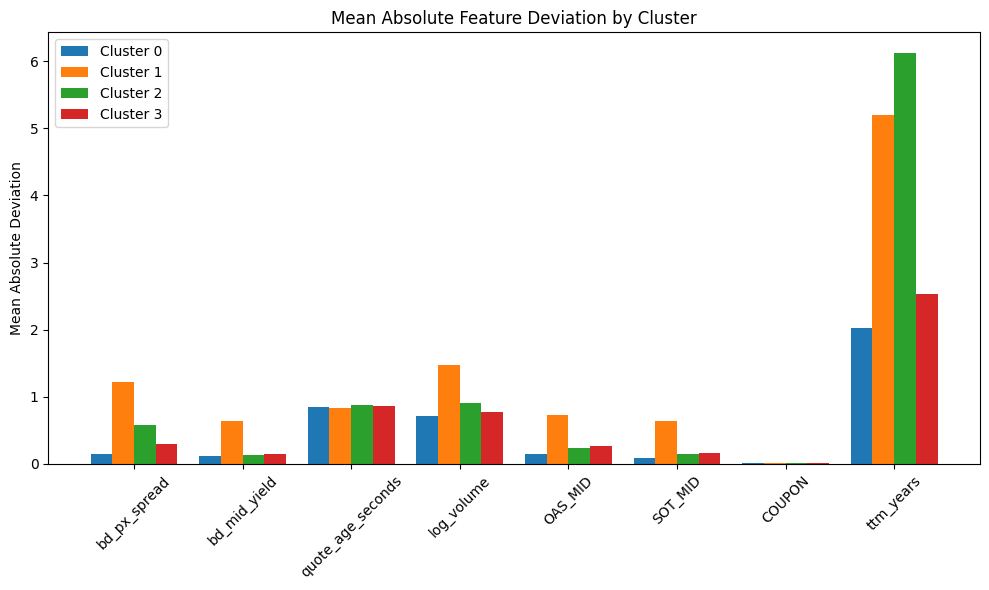

In [175]:
# preparing a grouped bar chart
clusters = cluster_feature_deviation.index
x = np.arange(len(features))
width = 0.2

plt.figure(figsize=(10,6))

#plot one set of bars for each cluster, clusters are offset horizontally
for i, c in enumerate(clusters):
    plt.bar(
        x + i*width,
        cluster_feature_deviation.loc[c].values,
        width=width,
        label=f"Cluster {c}"
    )

plt.xticks(x + width*1.5, features, rotation=45)
plt.ylabel("Mean Absolute Deviation")
plt.title("Mean Absolute Feature Deviation by Cluster")
plt.legend()
plt.tight_layout()
plt.show()